In [1]:
import pandas as pd
import matplotlib as cm
import matplotlib.pyplot as plt
import numpy as np


df1 = pd.read_csv('HoC-GE2024-results-by-candidate.csv')
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4515 entries, 0 to 4514
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   ONS ID                                 4515 non-null   object 
 1   ONS region ID                          4507 non-null   object 
 2   Constituency name                      4515 non-null   object 
 3   County name                            0 non-null      float64
 4   Region name                            4515 non-null   object 
 5   Country name                           4515 non-null   object 
 6   Constituency type                      4515 non-null   object 
 7   Party name                             4515 non-null   object 
 8   Party abbreviation                     4515 non-null   object 
 9   Electoral Commission party ID          4055 non-null   object 
 10  MNIS party ID                          4515 non-null   int64  
 11  Elec

In [2]:
df2 = pd.read_csv('HoC-GE2024-results-by-constituency.csv')

print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ONS ID                 650 non-null    object 
 1   ONS region ID          650 non-null    object 
 2   Constituency name      650 non-null    object 
 3   County name            0 non-null      float64
 4   Region name            650 non-null    object 
 5   Country name           650 non-null    object 
 6   Constituency type      650 non-null    object 
 7   Declaration time       0 non-null      float64
 8   Member first name      650 non-null    object 
 9   Member surname         650 non-null    object 
 10  Member gender          650 non-null    object 
 11  Result                 650 non-null    object 
 12  First party            650 non-null    object 
 13  Second party           650 non-null    object 
 14  Electorate             650 non-null    int64  
 15  Valid 

My implementation of k-means

In [3]:
import random

def k_means(k, points):
    dimensions = len(points[0])
    centroids = random.sample(points, k)
    clusters = [[] for _ in range(k)]
    while True:
        new_clusters = [[] for _ in range(k)]
        for point in points:
            closest_index = None
            closest_distance = 999999
            for i, centroid in enumerate(centroids):
                distance = np.sqrt(np.sum(np.pow(np.array(centroid)-np.array(point),2)))
                if distance<closest_distance:
                    closest_distance = distance
                    closest_index = i
            new_clusters[closest_index].append(point)
        new_clusters = [np.array(cluster) for cluster in new_clusters]
        new_centroids = []
        for cluster in new_clusters:
            new_centroid = []
            for dimension in range(dimensions):
                new_centroid.append(np.mean(cluster[:, dimension]))
            new_centroids.append(new_centroid)
        if [len(i) for i in clusters]==[len(i) for i in new_clusters]:
            break
        else:
            clusters = new_clusters
            centroids = new_centroids
    return clusters


We get vote share in each constituency, and also we prepare colors for scatter plot visualization

In [4]:
shares_by_party = df2.copy()
list_of_party_columns = ['Majority', 'Con', 'Lab', 'LD', 'RUK', 'Green', 'SNP', 'PC', 'DUP', 'SF', 'SDLP', 'UUP', 'APNI', 'All other candidates', 'Of which other winner']
for party in list_of_party_columns:
    shares_by_party[party] = shares_by_party[party]/shares_by_party['Valid votes']

color = {'Lab': 'red', 'Con': 'blue', 'LD': 'orange', 'Green': 'green', 'RUK': 'cyan', 'SNP': 'yellow'}
def get_party_color(party):
    if party in color:
        return color[party]
    return 'gray'

Lets try to classify constituencies by their conservative vs labour vote share. With k=3, we can see that liberal-democrat seats become separate from the others, while if we increase k further, we start to separate the big blob up. This has a practical utily in that we can start to see which seats are safe labour, which seats are safe conservative, which seats would labour and conservatives fight really hard for, and lastly, which seats are tough for conservatives to take from labour, but perhaps a different party would have a chance.


<ipython-input-5-02ecb1d94996>:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  shares_winner = shares_by_party[['First party', *[first_party, second_party]]][~shares_by_party['Region name'].isin(['Scotland', 'Wales', 'Northern Ireland'])][~shares_by_party['First party'].isin(['Spk', 'Ind'])]


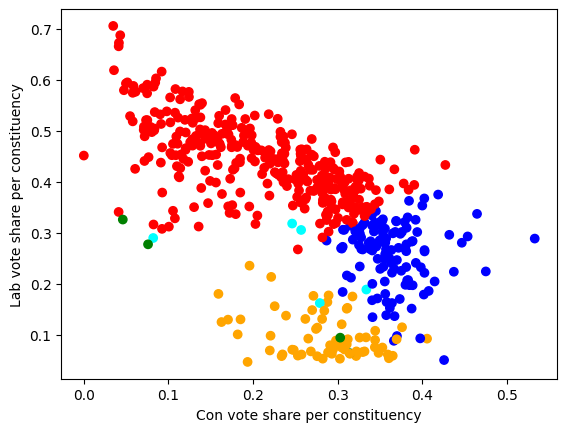

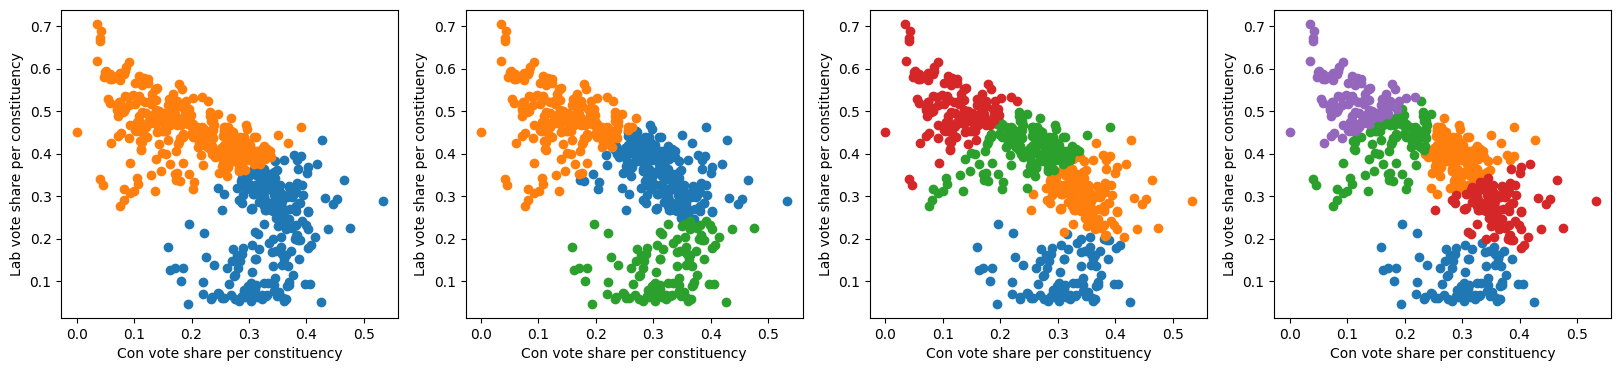

In [5]:
first_party = 'Con'
second_party = 'Lab'
shares_winner = shares_by_party[['First party', *[first_party, second_party]]][~shares_by_party['Region name'].isin(['Scotland', 'Wales', 'Northern Ireland'])][~shares_by_party['First party'].isin(['Spk', 'Ind'])]

x_line = shares_winner[first_party]
y_line = shares_winner[second_party]
color_array = [get_party_color(party) for party in shares_winner['First party']]

plt.scatter(x_line, y_line, color=color_array)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')
plt.show()

figure = plt.figure(figsize=(20, 4))

figure.add_subplot(1, 4, 1)
k=2
clusters = k_means(k, list(shares_winner[[first_party, second_party]].values))
[plt.scatter(cluster[:,0], cluster[:,1]) for cluster in clusters]
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 2)
k=3
clusters = k_means(k, list(shares_winner[[first_party, second_party]].values))
[plt.scatter(cluster[:,0], cluster[:,1]) for cluster in clusters]
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 3)
k=4
clusters = k_means(k, list(shares_winner[[first_party, second_party]].values))
[plt.scatter(cluster[:,0], cluster[:,1]) for cluster in clusters]
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 4)
k=5
clusters = k_means(k, list(shares_winner[[first_party, second_party]].values))
[plt.scatter(cluster[:,0], cluster[:,1]) for cluster in clusters]
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')
plt.show()

Comparing to scikit

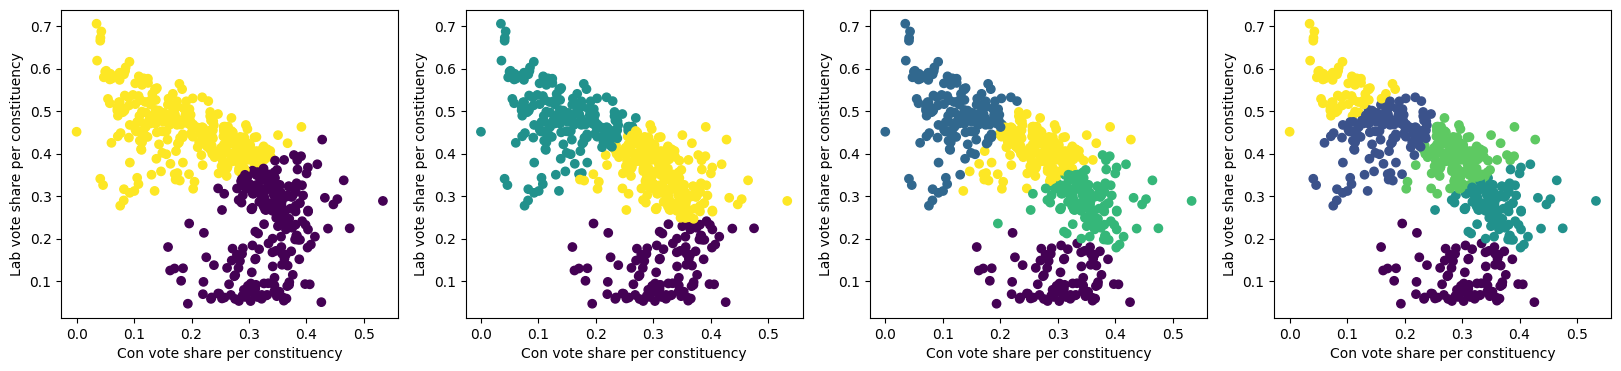

In [6]:
from sklearn.cluster import KMeans

X = list(shares_winner[[first_party, second_party]].values)

figure = plt.figure(figsize=(20, 4))

figure.add_subplot(1, 4, 1)
km = KMeans(n_clusters=2, n_init='auto', random_state=222)
km_labels = km.fit_predict(X)
plt.scatter([point[0] for point in X], [point[1] for point in X], c=km_labels)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 2)
km = KMeans(n_clusters=3, n_init='auto', random_state=222)
km_labels = km.fit_predict(X)
plt.scatter([point[0] for point in X], [point[1] for point in X], c=km_labels)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 3)
km = KMeans(n_clusters=4, n_init='auto', random_state=222)
km_labels = km.fit_predict(X)
plt.scatter([point[0] for point in X], [point[1] for point in X], c=km_labels)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 4)
km = KMeans(n_clusters=5, n_init='auto', random_state=222)
km_labels = km.fit_predict(X)
plt.scatter([point[0] for point in X], [point[1] for point in X], c=km_labels)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

plt.show()

Getting silhouette score - obviously 2-3 do the best, as we can clearly see 2 clusters in the image, though that is not the use case I displayed

Text(0, 0.5, 'Silhouette coefficient')

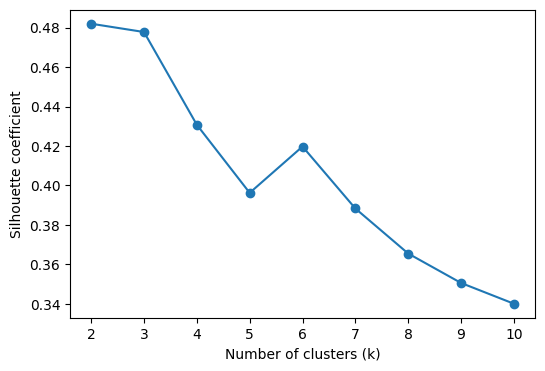

In [7]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
ks = list(range(2, 10 + 1))
for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=222)
    y_pred = km.fit_predict(X)
    score = silhouette_score(X, y_pred)
    silhouette_scores.append(score)

plt.figure(figsize=(6, 4), dpi=100)
plt.plot(ks, silhouette_scores, marker='o')
plt.xticks(ks)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette coefficient')

Moving on to Agglomerative Clustering - firstly setting up a helper funtion for dendogram, and then clustering.

In [8]:

# From scikit-learn examples:
# https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

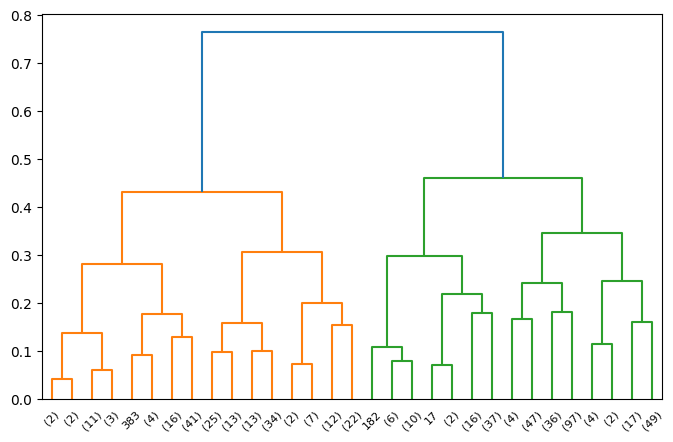

In [9]:
from sklearn.cluster import AgglomerativeClustering

hc0 = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    linkage='complete',
    metric='euclidean')
hc0.fit(X)

plt.figure(figsize=(8, 5))
plot_dendrogram(hc0, truncate_mode='level', p=4)

Seems to perfectly separate liberal democrats far better from k-means when there are more clusters

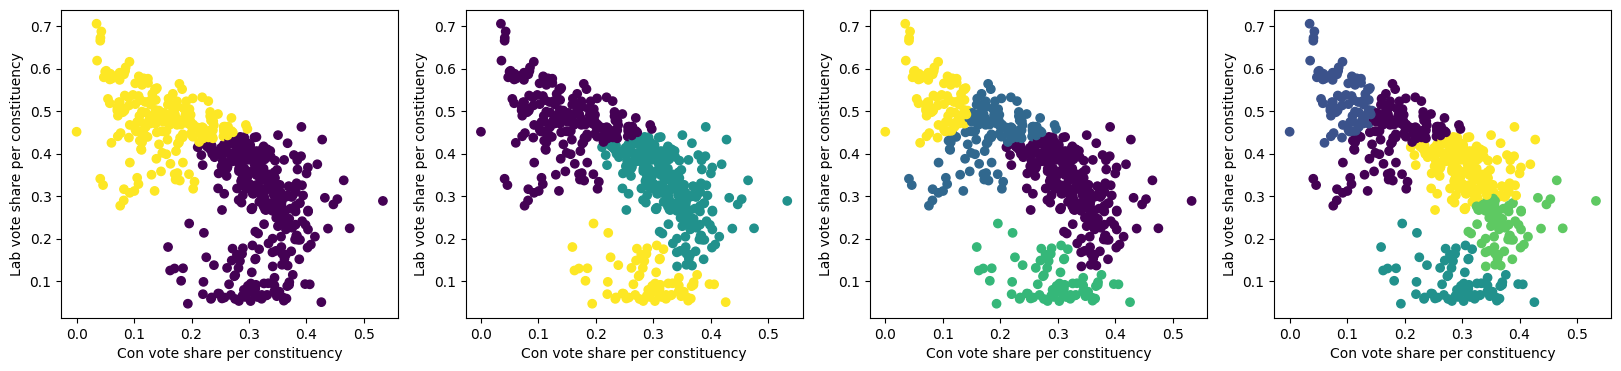

In [10]:
figure = plt.figure(figsize=(20, 4))

figure.add_subplot(1, 4, 1)
hc = AgglomerativeClustering(n_clusters=2, linkage='complete')
hc_labels = hc.fit_predict(X)
plt.scatter([point[0] for point in X], [point[1] for point in X], c=hc_labels)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 2)
hc = AgglomerativeClustering(n_clusters=3, linkage='complete')
hc_labels = hc.fit_predict(X)
plt.scatter([point[0] for point in X], [point[1] for point in X], c=hc_labels)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 3)
hc = AgglomerativeClustering(n_clusters=4, linkage='complete')
hc_labels = hc.fit_predict(X)
plt.scatter([point[0] for point in X], [point[1] for point in X], c=hc_labels)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

figure.add_subplot(1, 4, 4)
hc = AgglomerativeClustering(n_clusters=5, linkage='complete')
hc_labels = hc.fit_predict(X)
plt.scatter([point[0] for point in X], [point[1] for point in X], c=hc_labels)
plt.xlabel(first_party + ' vote share per constituency')
plt.ylabel(second_party + ' vote share per constituency')

plt.show()

This is not really a clustering use case, but it could also be used to strategise how much effort to put into protecting each seat. Graphs display labour vote share (%) vs their lead in votes over 2nd place party. If the seats are on far left, considering bad polling currently, one should probably give up on defending them. Ones on far right also probably, cynically, don't deserve much attention, as they are very safe. Most of the effort should be allocated to defending middle seats.

Putting this data together may be interesting, as, if you drive a regression line through it, then the seats below have likely been won, because there are a lot of competing parties, while if the seats are above the line, there is likely a coordinated opposition, but it has been defeated. This may require different strategic planning to address.

Agglomerative Clustering seems to put much more effort into separating safe seats out into different clusters.

<ipython-input-11-a8d9300a635c>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  majorities_vs_conservative_share = shares_by_party[['Majority', 'Lab']][shares_by_party['First party'].isin(['Lab'])][~shares_by_party['Region name'].isin(['Northern Ireland'])]


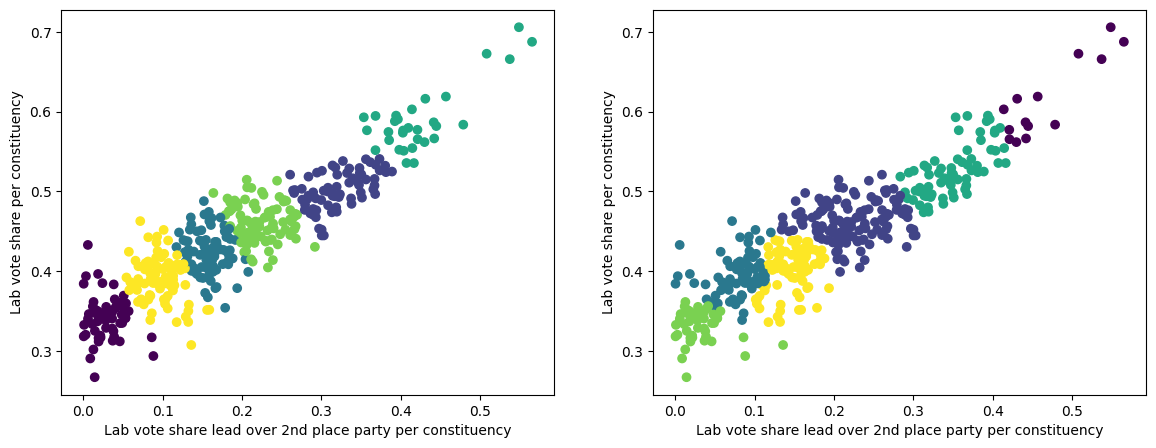

In [11]:
majorities_vs_conservative_share = shares_by_party[['Majority', 'Lab']][shares_by_party['First party'].isin(['Lab'])][~shares_by_party['Region name'].isin(['Northern Ireland'])]
majorities_vs_conservative_share = majorities_vs_conservative_share.values

figure = plt.figure(figsize=(14, 5))

figure.add_subplot(1, 2, 1)
km = KMeans(n_clusters=6, n_init='auto', random_state=222)
km_labels = km.fit_predict(majorities_vs_conservative_share)
plt.scatter([point[0] for point in majorities_vs_conservative_share], [point[1] for point in majorities_vs_conservative_share], c=km_labels)
plt.xlabel('Lab vote share lead over 2nd place party per constituency')
plt.ylabel('Lab vote share per constituency')

figure.add_subplot(1, 2, 2)
hc = AgglomerativeClustering(n_clusters=6, linkage='complete')
hc_labels = hc.fit_predict(majorities_vs_conservative_share)
plt.scatter([point[0] for point in majorities_vs_conservative_share], [point[1] for point in majorities_vs_conservative_share], c=hc_labels)
plt.xlabel('Lab vote share lead over 2nd place party per constituency')
plt.ylabel('Lab vote share per constituency')

plt.show()